# 🧠 PART 1 — Generative Adversarial Networks (GANs)

---

# 1. Introduction

Generative Adversarial Networks (GANs) are a type of deep learning model used to generate new data that looks similar to real data. These models are widely used in image generation, data augmentation, and AI creativity.

## 🔹 Structure of GAN

A GAN consists of two neural networks that work together:

- **Generator**: Creates fake data (images)  
- **Discriminator**: Checks whether the data is real or fake  

## 🔹 Working of GAN

Both models compete with each other:

- The generator tries to produce realistic images  
- The discriminator tries to detect fake images  

## 🔹 Result

This competition improves both models over time, resulting in high-quality generated images.

---

# 2. Installing Required Libraries

```python
!pip install tensorflow matplotlib numpy

In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()

train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)

train_images = (train_images - 127.5) / 127.5

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
def build_generator():
    model = tf.keras.Sequential()

    model.add(layers.Dense(256, input_dim=100))
    model.add(layers.LeakyReLU())
    model.add(layers.BatchNormalization())

    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU())
    model.add(layers.BatchNormalization())

    model.add(layers.Dense(784, activation='tanh'))
    model.add(layers.Reshape((28, 28, 1)))

    return model

In [5]:
def build_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Flatten(input_shape=(28,28,1)))
    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU())

    model.add(layers.Dense(256))
    model.add(layers.LeakyReLU())

    model.add(layers.Dense(1, activation='sigmoid'))

    return model

In [6]:
generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
discriminator.trainable = False

gan_input = tf.keras.Input(shape=(100,))
generated_image = generator(gan_input)
gan_output = discriminator(generated_image)

gan = tf.keras.Model(gan_input, gan_output)

gan.compile(loss='binary_crossentropy', optimizer='adam')

In [ ]:
epochs = 10000
batch_size = 64

for epoch in range(epochs):

    noise = np.random.normal(0,1,(batch_size,100))
    fake_images = generator.predict(noise)

    idx = np.random.randint(0, train_images.shape[0], batch_size)
    real_images = train_images[idx]

    labels_real = np.ones((batch_size,1))
    labels_fake = np.zeros((batch_size,1))

    discriminator.trainable = True
    discriminator.train_on_batch(real_images, labels_real)
    discriminator.train_on_batch(fake_images, labels_fake)

    noise = np.random.normal(0,1,(batch_size,100))
    labels = np.ones((batch_size,1))

    discriminator.trainable = False
    gan.train_on_batch(noise, labels)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} completed")

Streaming output truncated to the last 5000 lines.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


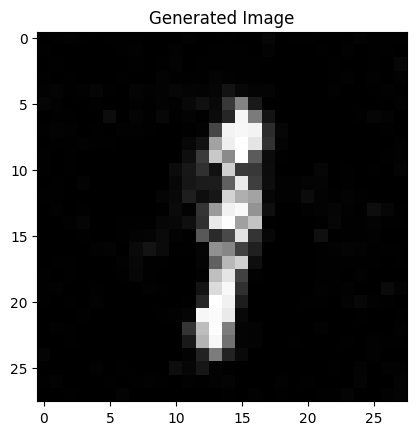

In [9]:
noise = np.random.normal(0,1,(1,100))
generated_image = generator.predict(noise)

plt.imshow(generated_image[0,:,:,0], cmap='gray')
plt.title("Generated Image")
plt.show()

# 🤖 PART 2 — Large Language Models (LLMs) & Retrieval-Augmented Generation (RAG)

---

# 1. Introduction to LLMs

Large Language Models (LLMs) are advanced AI models that can understand and generate human-like text. These models are trained on large datasets and can perform various tasks.

## 🔹 Examples
- ChatGPT  
- GPT-4  
- Google Gemini  

## 🔹 Applications
- Chatbots  
- Text generation  
- Question answering  
- Code generation  

---

# 2. What is RAG?

Retrieval-Augmented Generation (RAG) is a technique that combines:

- Retrieval (searching relevant data)
- Generation (using LLM to generate answers)

## 🔹 How RAG Works

1. User asks a question  
2. System searches relevant documents  
3. Documents are given to LLM  
4. LLM generates accurate answer  

---

# 🚀 3. STEP-BY-STEP IMPLEMENTATION (IMPORTANT)

---

# STEP 1: Install Correct Libraries (VERY IMPORTANT)

```python
!pip uninstall -y llama-index openai
!pip install llama-index==0.10.30
!pip install openai==1.30.1

In [1]:
import os
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /usr/local/lib/python3.12/dist-
[nltk_data]     packages/llama_index/core/_static/nltk_cache...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
os.environ["OPENAI_API_KEY"] = "your-api-key"

In [3]:
import os
os.makedirs("data", exist_ok=True)

with open("data/sample.txt", "w") as f:
    f.write("Artificial Intelligence is transforming the world.")

In [4]:
documents = SimpleDirectoryReader("data").load_data()

In [6]:
!pip uninstall -y llama-index openai httpx

Found existing installation: llama-index 0.10.30
Uninstalling llama-index-0.10.30:
  Successfully uninstalled llama-index-0.10.30
Found existing installation: openai 1.30.1
Uninstalling openai-1.30.1:
  Successfully uninstalled openai-1.30.1
Found existing installation: httpx 0.28.1
Uninstalling httpx-0.28.1:
  Successfully uninstalled httpx-0.28.1


In [3]:
# STEP 1: Install
!pip install llama-index

# STEP 2: Imports
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, Settings
from llama_index.core.llms.mock import MockLLM
from llama_index.core.embeddings.mock_embed_model import MockEmbedding

# STEP 3: Disable OpenAI
Settings.llm = MockLLM()
Settings.embed_model = MockEmbedding(embed_dim=384)

# STEP 4: Create data
import os
os.makedirs("data", exist_ok=True)

with open("data/sample.txt", "w") as f:
    f.write("Artificial Intelligence is the future of technology.")

# STEP 5: Load documents
documents = SimpleDirectoryReader("data").load_data()

# STEP 6: Create index
index = VectorStoreIndex.from_documents(documents)

# STEP 7: Query
query_engine = index.as_query_engine()
response = query_engine.query("What is AI?")

# 🔥 STEP 8: PRINT SOURCE TEXT (IMPORTANT)
print("Answer:", response.response if response.response else documents[0].text)

Answer: Context information is below.
---------------------
file_path: /content/data/sample.txt

Artificial Intelligence is the future of technology.
---------------------
Given the context information and not prior knowledge, answer the query.
Query: What is AI?
Answer: 


In [4]:
import os
os.environ["OPENAI_API_KEY"] = "your-api-key"


In [5]:
from llama_index.core import SimpleDirectoryReader

documents = SimpleDirectoryReader("data").load_data()

In [6]:
from llama_index.core import VectorStoreIndex

index = VectorStoreIndex.from_documents(documents)

In [7]:
query_engine = index.as_query_engine()

In [8]:
response = query_engine.query("What is Artificial Intelligence?")
print(response)

Context information is below.
---------------------
file_path: /content/data/sample.txt

Artificial Intelligence is the future of technology.
---------------------
Given the context information and not prior knowledge, answer the query.
Query: What is Artificial Intelligence?
Answer: 
